# Mapping Florida's old and new congressional districts

Florida was one of the states that redrew its congressional map for the 120th Congress
(see `redistricting_changes.ipynb` for the population-level analysis). This notebook
draws the old (119th Congress) and new (120th Congress) district maps side by side,
highlighting districts 12 and 15 so the change in their boundaries is easy to spot.

## A simplification worth noting
Census blocks are not perfectly clipped to the shoreline - some blocks along the coast
and around lakes include a bit of water. Blocks that are 100% water are dropped once
they pass a minimum size (`MIN_WATER_BLOCK_AREA_M2`), so large water bodies like the
open bay around the Florida Keys render as water, while small ponds and canals stay
part of the land silhouette.

Dropping those water-only blocks leaves small notches along the coastline, and raising
`MIN_WATER_BLOCK_AREA_M2` to drop more/bigger lakes makes that worse. We clean this up
in three steps:

1. A morphological closing (`CLOSE_BUFFER_M`) on the combined land shape fills the
   notches, then merges each one into whichever single district it touches. A notch
   touching more than one district (e.g. a small lake at a three-way district
   junction) is left unfilled here, since merging it into just one district would
   grow that district past where its neighbors' boundaries still curve around the
   old notch.
2. A topology-preserving simplification (`SIMPLIFY_TOLERANCE_M`, via the `topojson`
   package) smooths the remaining block-edge jaggedness. Simplifying each district
   polygon independently (e.g. with plain `GeoSeries.simplify`) desyncs borders that
   used to be shared exactly, leaving thin sliver gaps between neighboring districts -
   `topojson` avoids this by simplifying shared borders once, as shared arcs, so
   adjacent districts stay perfectly aligned.
3. Small disconnected islands and small enclosed lakes/sounds (`MIN_FEATURE_AREA_M2`)
   are dropped, so the coastline reads as a handful of major, recognizable features
   rather than a scatter of tiny ones. This runs once per district, then once more on
   the union of every district - a notch left unfilled in step 1 because it touched
   several districts isn't an interior hole of any single one of them, but it *is* an
   interior hole of the combined state shape, so the second pass is what actually
   catches it.

All three constants are tunable if you want a different tradeoff between detail and
cleanliness.

## Required data
This notebook needs the TIGER/Line 2020 census block shapefile for Florida
(`tl_2020_12_tabblock20.zip`), placed in `data/`. See the README for where to get it.

In [1]:
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import topojson as tp
from shapely.geometry import MultiPolygon, Polygon
from shapely.ops import unary_union

In [2]:
# Plot styling
# NOTE: I use dark mode for my notebooks; the plots will therefore look
# nicer if you use dark mode in your browser on GitHub.

INK = "#FFFFFF"

plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.facecolor": "#FFFFFF",
    "savefig.facecolor": "#FFFFFF",
    "axes.titlecolor": INK,
    "text.color": INK,
    "font.size": 12,
})

WATER_COLOR = "#FFFFFF"
LAND_COLOR = "#ECE0D0"
BOUNDARY_COLOR = "#2E2D31"
OVERLAY_ALPHA = 1.
HIGHLIGHT_COLORS = {"01": "#5481F5", "03": "#000C48"}  # district -> overlay color

## Load data

In [3]:
DATA_DIR = Path("data")
FIPS = "37"
ABBR = "NC"

# NAD83(HARN) / Florida GDL Albers - a projected, meters-based CRS suited to
# statewide Florida maps. We need real distance units for the smoothing below.
PROJECTED_CRS = "EPSG:3086"

# Blocks that are 100% water are dropped only past this size, so small ponds/canals
# stay part of the land silhouette and only large water bodies (bays, the ocean) show as water.
MIN_WATER_BLOCK_AREA_M2 = 5_000_000

# Dropping water-only blocks near the coast leaves small notches in the land silhouette.
# A morphological closing (buffer out, then back in) fills those without changing the
# overall shape. SIMPLIFY_TOLERANCE_M then smooths the remaining block-edge jaggedness.
CLOSE_BUFFER_M = 1000
SIMPLIFY_TOLERANCE_M = 250

# After simplifying, drop any disconnected island or enclosed lake/sound smaller than
# this so the coastline reads as a handful of major, recognizable features instead of
# a scatter of tiny islands and ponds. There's a natural gap in NC's feature sizes
# between a few km^2 (small islands/ponds) and several hundred km^2 (real landmasses/
# sounds), so most thresholds in that range work equally well - 20 km^2 also clears
# a couple of ~11-15 km^2 inland lakes that would otherwise still read as clutter.
MIN_FEATURE_AREA_M2 = 20_000_000

In [4]:
def load_cd_assignments(geoid_and_cd: pd.DataFrame, cd_column: str) -> pd.DataFrame:
    """Reduces a block assignment file to just GEOID and a renamed district column."""
    return geoid_and_cd[["GEOID", "CDFP"]].rename(columns={"CDFP": cd_column})


new_cd_df = load_cd_assignments(pd.read_csv(DATA_DIR / f"CD120_{FIPS}.txt", dtype=str), "new_cd")

with zipfile.ZipFile(DATA_DIR / "cd119.zip") as zf:
    with zf.open("NationalCD119.txt") as f:
        national_cd119 = pd.read_csv(f, dtype=str)

old_cd_df = load_cd_assignments(national_cd119, "old_cd")
old_cd_df = old_cd_df[old_cd_df["GEOID"].str[:2] == FIPS]

print(old_cd_df.shape, new_cd_df.shape)

(236638, 2) (236638, 2)


In [5]:
def load_state_blocks_gdf(fips: str) -> gpd.GeoDataFrame:
    """Loads TIGER/Line 2020 census block geometries for one state.

    Blocks that are 100% water are dropped once their area passes
    MIN_WATER_BLOCK_AREA_M2, so district polygons don't bulge out over large
    bodies of water (e.g. open bay/ocean blocks in the Florida Keys) while
    small ponds and canals stay part of the land silhouette.

    Args:
        fips: Two-digit state FIPS code, matching the shapefile's name.

    Returns:
        GeoDataFrame with GEOID and geometry (in PROJECTED_CRS), one row per
        land-containing census block.
    """
    path = DATA_DIR / f"tl_2020_{fips}_tabblock20/tl_2020_{fips}_tabblock20.shp"
    gdf = gpd.read_file(path).to_crs(PROJECTED_CRS)
    all_water = gdf["ALAND20"] == 0
    gdf = gdf[~(all_water & (gdf["AWATER20"] > MIN_WATER_BLOCK_AREA_M2))]
    return gdf[["GEOID20", "geometry"]].rename(columns={"GEOID20": "GEOID"})


blocks_gdf = load_state_blocks_gdf(FIPS)
blocks_gdf = blocks_gdf.merge(old_cd_df, on="GEOID", how="inner").merge(new_cd_df, on="GEOID", how="inner")
blocks_gdf.shape

(236399, 4)


In [6]:
def _fill_water_notches(districts: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Fills small coastline/lake notches left by dropped water-only blocks.

    A morphological closing (buffer out, then back in) on the *combined* land
    shape finds the notch-filling area without needing to touch each district's
    geometry independently. Each notch is then merged into whichever district
    it actually touches, so districts stay disjoint (no new overlaps) and every
    other district's boundary is left completely untouched (no new gaps).

    A notch that touches more than one district (e.g. a small lake sitting
    right at a district junction) is left unfilled instead: merging it into
    just one of those districts would grow that district's polygon past where
    its neighbors' boundaries still curve around the old notch, producing a
    sliver mismatch. This isn't a problem for the final map: such a notch is
    small (else it wouldn't have been dropped as water in the first place) and
    fully enclosed by the state's overall land shape, so `_drop_small_features`
    cleans it up later at the whole-state level, where there's no question of
    which district it belongs to.

    Args:
        districts: One row per district, with columns cd and geometry.

    Returns:
        Copy of districts with unambiguous water notches merged into district
        geometries.
    """
    land = unary_union(districts.geometry.values)
    closed_land = land.buffer(CLOSE_BUFFER_M).buffer(-CLOSE_BUFFER_M)
    fill = closed_land.difference(land)
    pieces = [g for g in getattr(fill, "geoms", [fill]) if not g.is_empty and g.area > 1]
    if not pieces:
        return districts

    pieces_gdf = gpd.GeoDataFrame({"piece_id": range(len(pieces))}, geometry=pieces, crs=districts.crs)
    joined = gpd.sjoin(pieces_gdf, districts[["cd", "geometry"]], how="left", predicate="intersects")
    unambiguous = joined.groupby("piece_id").filter(lambda g: g["cd"].nunique() == 1)
    fill_by_cd = unambiguous.dropna(subset=["cd"]).groupby("cd")["piece_id"].apply(list)

    districts = districts.copy()
    districts["geometry"] = [
        unary_union([geom] + [pieces[i] for i in fill_by_cd[cd]]) if cd in fill_by_cd else geom
        for cd, geom in zip(districts["cd"], districts.geometry)
    ]
    return districts


def _flatten_polygons(geom: Polygon | MultiPolygon) -> list[Polygon]:
    """Recursively extracts Polygon parts, dropping non-polygonal components.

    make_valid on a self-intersecting geometry can return a GeometryCollection
    mixing polygons with degenerate points/lines; those carry no area and are
    dropped here so downstream area-based filtering only sees real polygons.
    """
    if geom.geom_type == "Polygon":
        return [geom]
    if hasattr(geom, "geoms"):
        return [p for g in geom.geoms for p in _flatten_polygons(g)]
    return []


def _drop_small_features(geom: Polygon | MultiPolygon, min_area: float) -> Polygon | MultiPolygon:
    """Drops disconnected polygon parts and interior holes below min_area.

    Removes small islands (separate polygon parts) and small lakes/ponds
    (interior rings) so the coastline reads as a few major features rather
    than a scatter of tiny ones. The largest part is always kept even if it's
    smaller than min_area, so the geometry can never be dropped entirely.

    A small lake shared between two districts isn't an interior ring of
    either district's own polygon (it's a dent shared by both their exterior
    boundaries, not fully enclosed by one), so calling this per-district
    misses it. Calling it once on the union of all districts catches every
    fully-enclosed small hole regardless of how many districts border it,
    with no need to figure out which district it "belongs" to.

    Args:
        geom: A polygon or multipolygon to clean up - either one district's
            geometry, or the union of every district.
        min_area: Minimum area (in the geometry's CRS units squared) for a
            part or hole to be kept.

    Returns:
        The cleaned-up geometry.
    """
    parts = _flatten_polygons(geom)
    kept_parts = [p for p in parts if p.area >= min_area] or [max(parts, key=lambda p: p.area)]
    cleaned = [
        Polygon(p.exterior, [ring for ring in p.interiors if Polygon(ring).area >= min_area])
        for p in kept_parts
    ]
    return cleaned[0] if len(cleaned) == 1 else MultiPolygon(cleaned)


def dissolve_districts(blocks_gdf: gpd.GeoDataFrame, cd_column: str) -> gpd.GeoDataFrame:
    """Dissolves block geometries into one polygon per congressional district.

    Simplifying each district's dissolved polygon independently (e.g. with
    plain `GeoSeries.simplify`) desyncs borders that used to be shared exactly,
    since Douglas-Peucker simplification has no notion of a shared edge. The
    mismatches show up as thin sliver gaps/overlaps between neighboring
    districts. `topojson` avoids this by building a topology where shared
    borders are stored once as shared arcs, simplifying those arcs, and
    reconstructing polygons from them - so adjacent districts stay exactly
    aligned.

    Args:
        blocks_gdf: Block-level geometries joined to district assignments.
        cd_column: Name of the district column to dissolve by.

    Returns:
        GeoDataFrame with one row per district: cd, geometry.
    """
    districts = blocks_gdf[[cd_column, "geometry"]].dissolve(by=cd_column).reset_index()
    districts = districts.rename(columns={cd_column: "cd"})
    districts = _fill_water_notches(districts)

    topology = tp.Topology(districts, prequantize=False, topology=True)
    simplified = topology.toposimplify(SIMPLIFY_TOLERANCE_M).to_gdf()
    simplified["geometry"] = simplified.geometry.make_valid()
    simplified["geometry"] = simplified.geometry.apply(_drop_small_features, min_area=MIN_FEATURE_AREA_M2)
    return simplified


old_districts_gdf = dissolve_districts(blocks_gdf, "old_cd")
new_districts_gdf = dissolve_districts(blocks_gdf, "new_cd")

# Small lakes shared between districts survive the per-district cleanup above (see
# _drop_small_features), so declutter once more on the combined state shape, where
# they're unambiguously fully-enclosed holes.
land_geometry = _drop_small_features(new_districts_gdf.union_all(), MIN_FEATURE_AREA_M2)

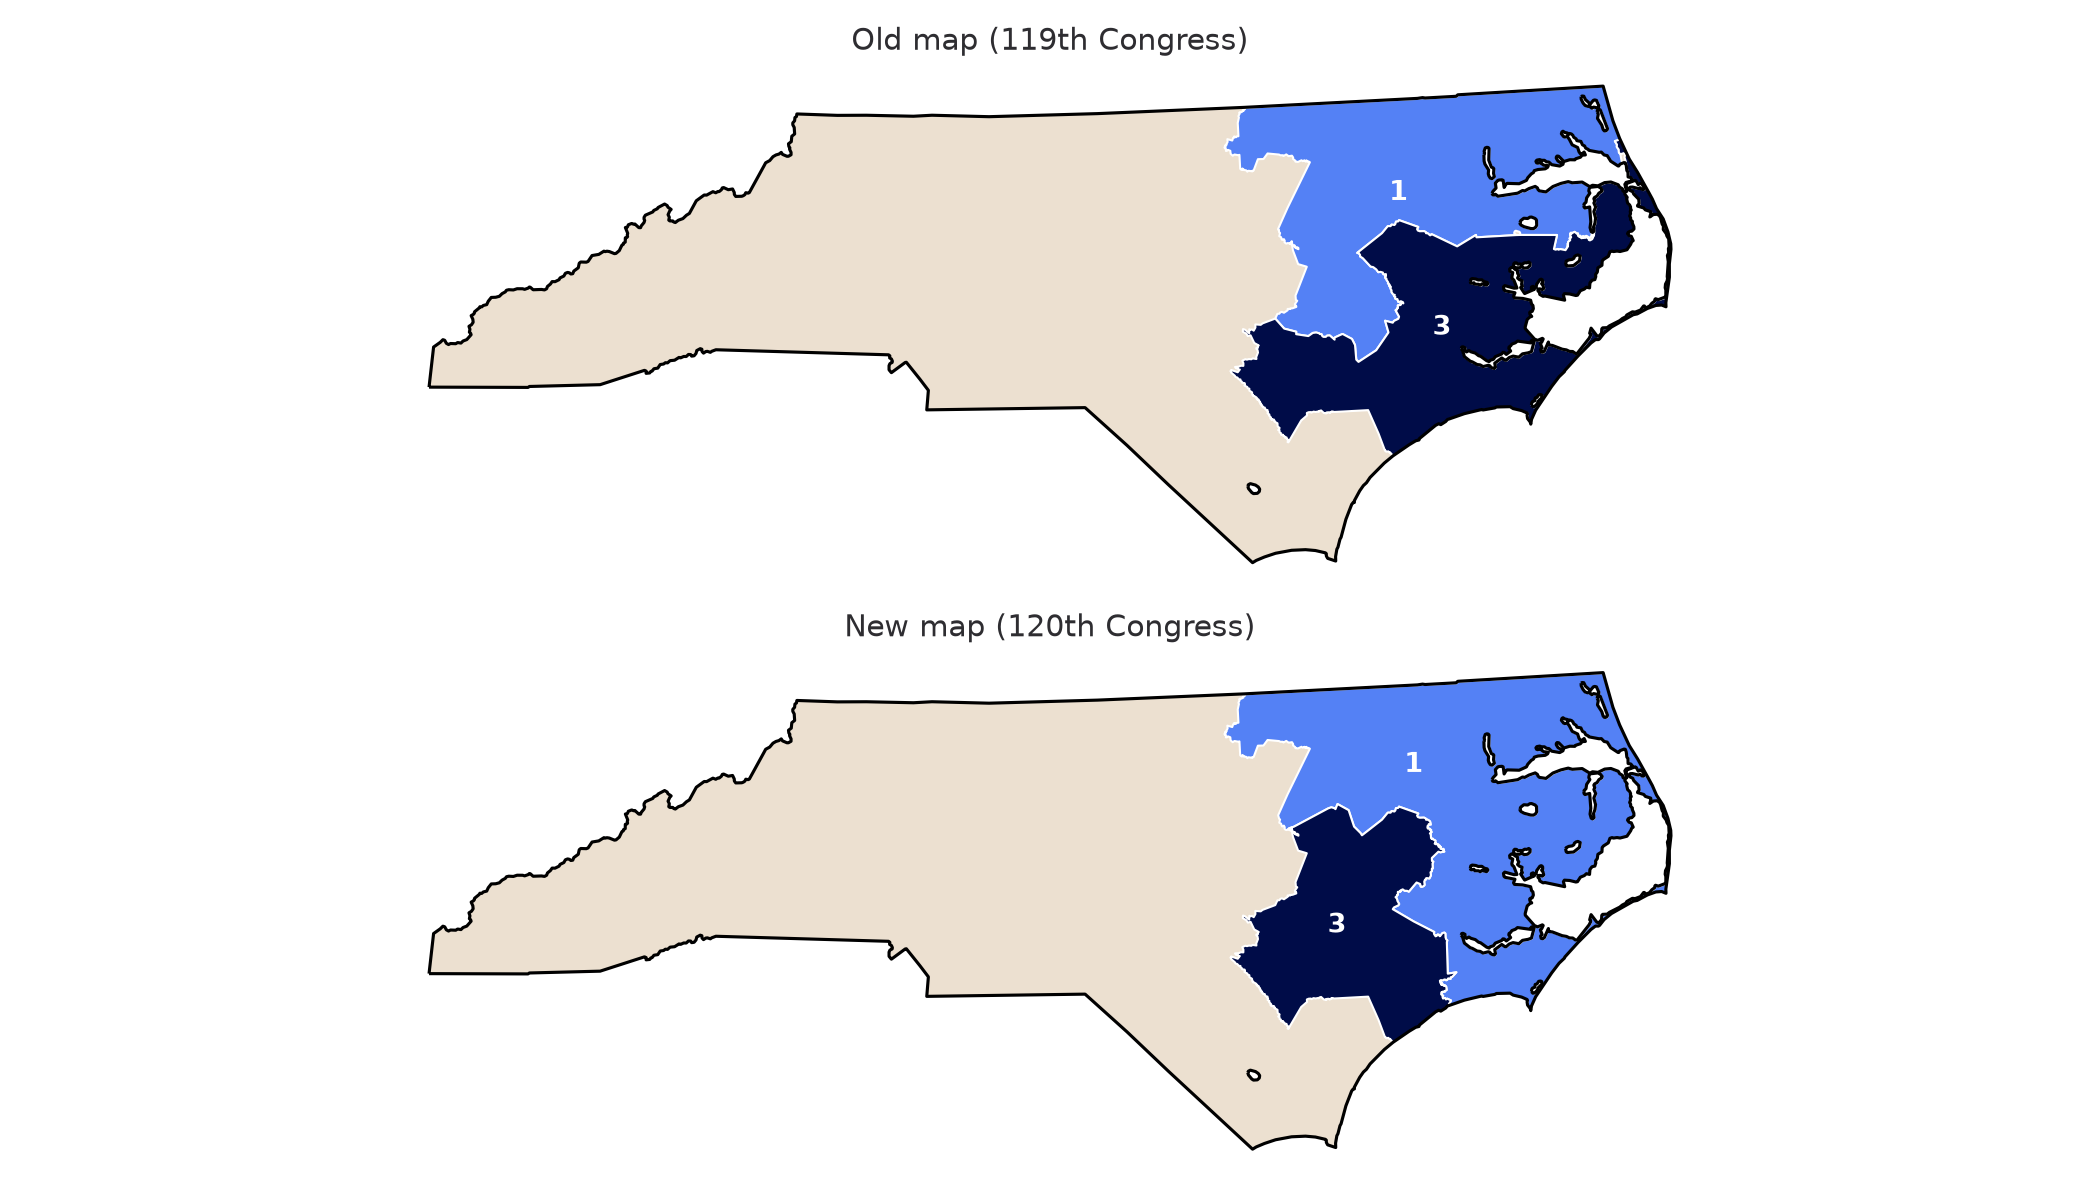

In [7]:
def plot_district_map(ax: plt.Axes, districts_gdf: gpd.GeoDataFrame, title: str, offset = (0,0,0,0)) -> None:
    """Draws one map: water background, green land, black district boundaries,
    with districts 1 and 3 highlighted and labeled."""
    ax.set_facecolor(WATER_COLOR)
    gpd.GeoSeries([land_geometry]).plot(ax=ax, color=LAND_COLOR, edgecolor="none")

    for cd, color in HIGHLIGHT_COLORS.items():
        district = districts_gdf[districts_gdf["cd"] == cd]
        district.plot(ax=ax, facecolor=color, alpha=OVERLAY_ALPHA, edgecolor='w', linewidth=1)
        label_point = district.geometry.iloc[0].representative_point()
        if cd == '01':
            xloc = label_point.x + offset[0]
            yloc = label_point.y + offset[1]
        if cd == '03':
            xloc = label_point.x + offset[2]
            yloc = label_point.y + offset[3]
        ax.text(
            xloc, yloc, cd[1:],
            ha="center", va="center", fontsize=13, fontweight="bold", color="white",
        )

    #districts_gdf.plot(ax=ax, facecolor="none", edgecolor=BOUNDARY_COLOR, linewidth=0.5)
    gpd.GeoSeries([land_geometry]).boundary.plot(ax=ax, edgecolor='k')
    minx, miny, maxx, maxy = land_geometry.bounds
    pad_x, pad_y = (maxx - minx) * 0.05, (maxy - miny) * 0.05
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_axis_off()
    ax.set_title(title, color = '#2E2D31')


fig, (ax_old, ax_new) = plt.subplots(2, 1)
plot_district_map(ax_old, old_districts_gdf, "Old map (119th Congress)", offset = (40000,20000,-8000,-20000))
plot_district_map(ax_new, new_districts_gdf, "New map (120th Congress)", offset = (-60000,50000.,0., 0.))
plt.tight_layout()
plt.savefig('nc_maps.png', bbox_inches='tight')
plt.show()

/Users/christian/projects/redistricting-wars/.venv/lib/python3.12/site-packages/geopandas/tools/overlay.py:375: UserWarning: `keep_geom_type=True` in overlay resulted in 25 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


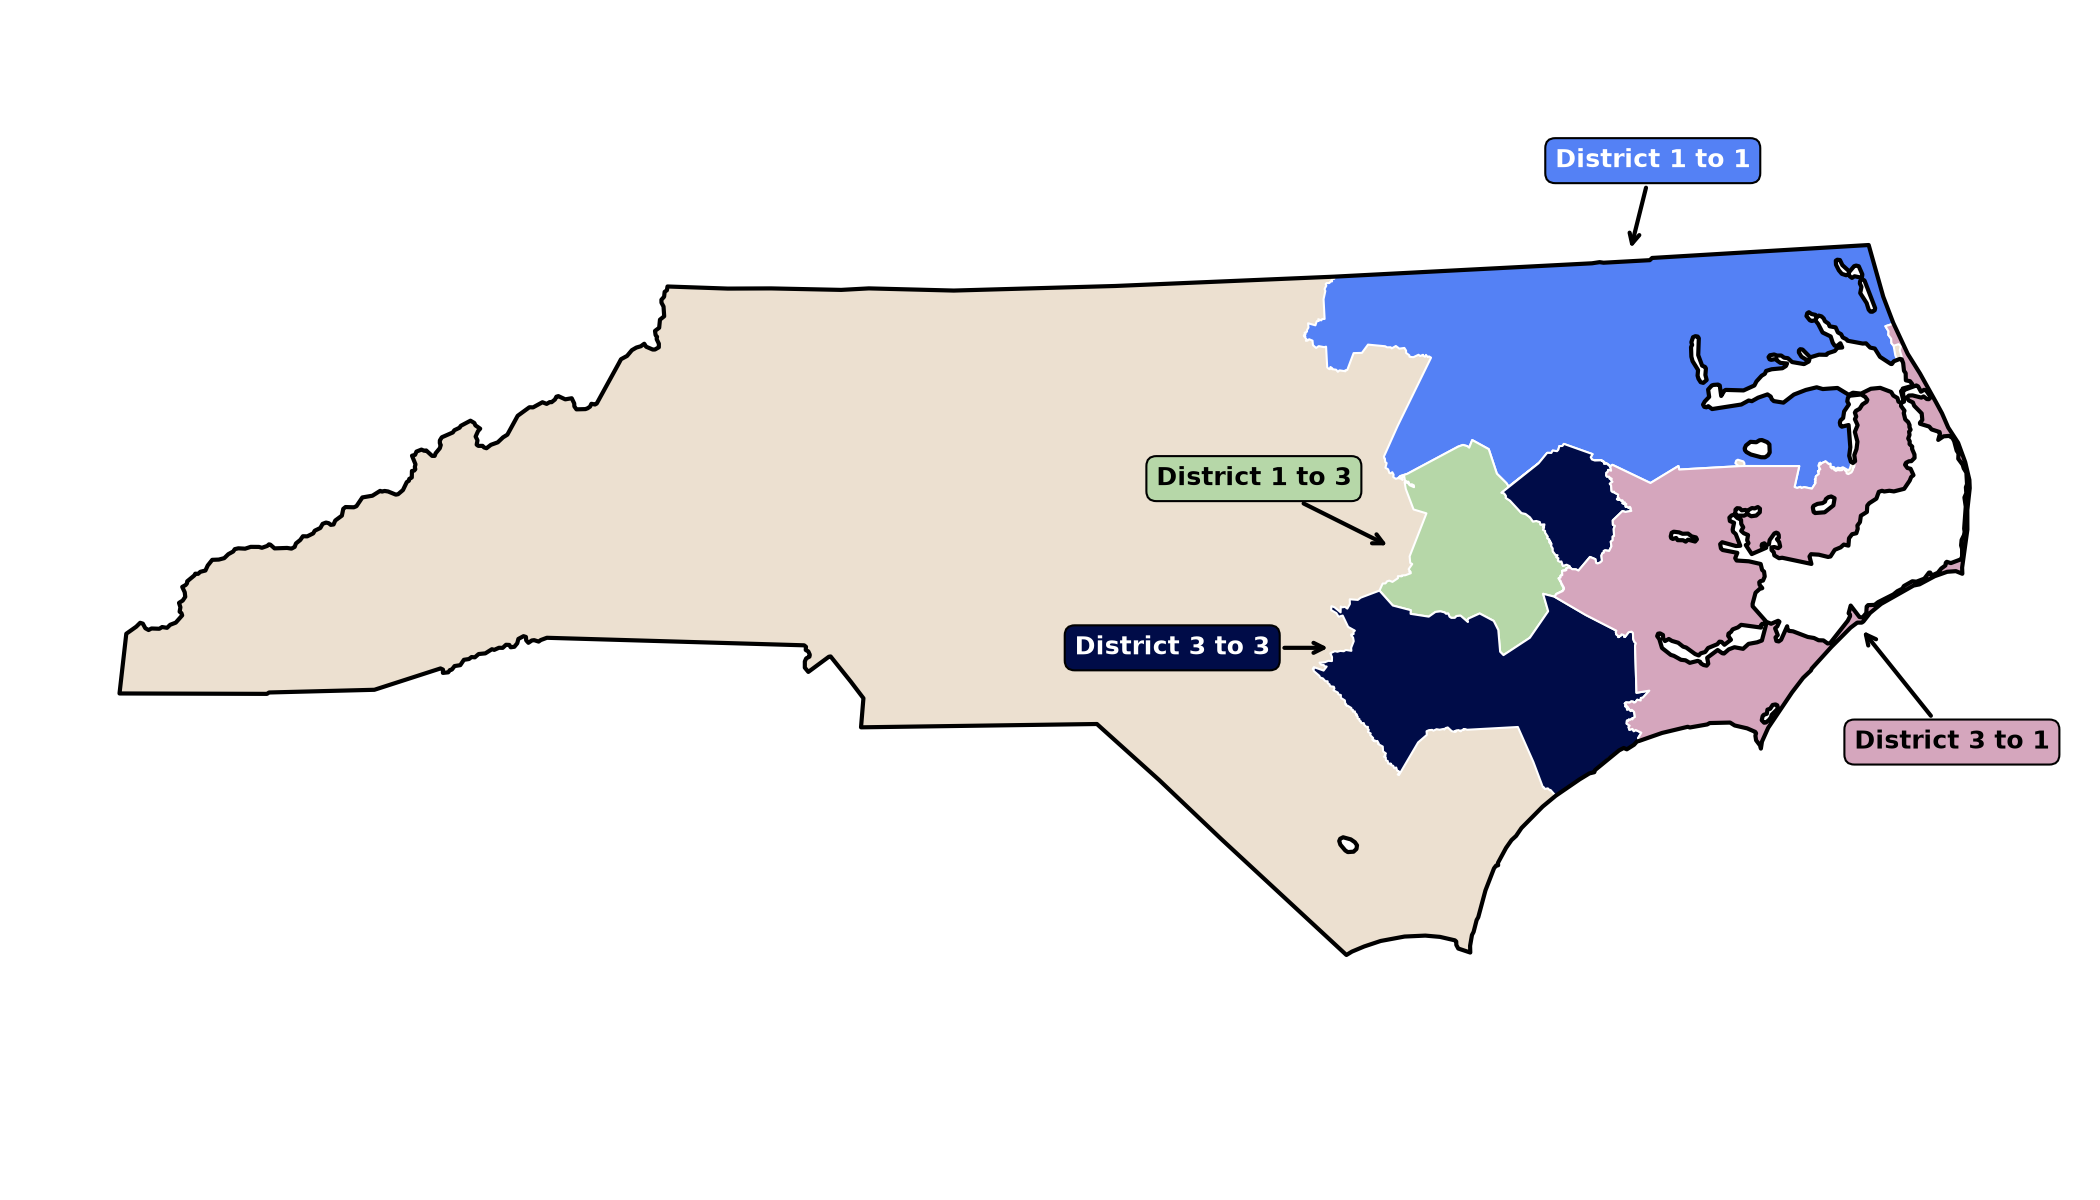

In [36]:
old = old_districts_gdf.loc[[0, 2]].reset_index()   # keeps 'cd' as a column
new = new_districts_gdf.loc[[0, 2]].reset_index()

pieces = gpd.overlay(old, new, how='intersection')  # cols: cd_1 (old), cd_2 (new)

vals = ('01', '03')   # or ('01', '03') — match what you just printed

parts = {
    (o, n): pieces[(pieces.cd_1 == o) & (pieces.cd_2 == n)].reset_index(drop=True)
    for o in vals for n in vals
}
old1_new1, old1_new3, old3_new1, old3_new3 = (
    parts[(vals[0], vals[0])], parts[(vals[0], vals[1])],
    parts[(vals[1], vals[0])], parts[(vals[1], vals[1])],
)

# Each entry: (piece gdf, fill color, label text, (dx, dy) offset of the label
# box from the piece's anchor point). Adjust the offsets to taste.
SHADED_PIECES = [
    (old1_new1, '#5481F5', 'District 1 to 1', (40000, 90000),(30000, 50000), 'w'),
    (old1_new3, '#B6D7A8', 'District 1 to 3', (-100000, 30000),(-40000, 0), 'k'),
    (old3_new3, '#000C48', 'District 3 to 3', (-140000, 20000),(-70000, 20000), 'w'),
    (old3_new1, '#D5A6BD', 'District 3 to 1', (60000, -90000),(20000, -40000), 'k'),
]


def plot_shaded_map(ax: plt.Axes, land: gpd.GeoSeries, pieces: list) -> None:
    """Draws the shaded overlap map, with each piece labeled by a rounded
    text box (matching the piece's fill color) connected by an arrow to a
    point on that piece.

    Args:
        ax: Axes to draw on.
        land: Background land silhouette.
        pieces: List of (gdf, color, label_text, (dx, dy)) tuples, where
            (dx, dy) shifts the label box away from the piece's anchor point.
    """
    ax.set_facecolor(WATER_COLOR)
    land.plot(ax=ax, color=LAND_COLOR, edgecolor="none")
    for gdf, color, _, _, _,_ in pieces:
        gdf.plot(color=color, ax=ax, edgecolor='w')
    land.plot(ax=ax, facecolor='none', edgecolor="k", linewidth=2.)

    for gdf, color, label, (dx, dy), (dax, day), fontcolor in pieces:
        anchor = gdf.geometry.union_all().representative_point()
        ax.annotate(
            label,
            xy=(anchor.x+dax, anchor.y+day),
            xytext=(anchor.x + dx, anchor.y + dy),
            ha="center", va="center", fontsize=12, fontweight="bold", color=fontcolor,
            arrowprops=dict(arrowstyle="->", color="k", linewidth=2.),
            bbox=dict(boxstyle="round,pad=0.4", facecolor=color, edgecolor="k"),
        )

    minx, miny, maxx, maxy = land_geometry.bounds
    pad_x, pad_y = (maxx - minx) * 0.05, (maxy - miny) * 0.05
    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)
    ax.set_axis_off()


fig, ax = plt.subplots(1, 1)
plot_shaded_map(ax, gpd.GeoSeries([land_geometry]), SHADED_PIECES)
plt.tight_layout()
plt.savefig('nc_colorful.png', bbox_inches='tight')
plt.show()